In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from glob import glob

In [118]:
ap_df = pd.read_csv("air_pollution_data.csv")
ap_df.columns = [col.strip() for col in ap_df.columns]
ap_df.head()

,IndicatorCode,Indicator,ValueType,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,...,FactValueUoM,FactValueNumericLowPrefix,FactValueNumericLow,FactValueNumericHighPrefix,FactValueNumericHigh,Value,FactValueTranslationID,FactComments,Language,DateModified
0,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AFR,Africa,Country,KEN,Kenya,Year,2019,...,NaN,NaN,6.29,NaN,13.74,10.01 [6.29-13.74],NaN,NaN,EN,2022-08-11T16:00:00.000Z
1,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,TTO,Trinidad and Tobago,Year,2019,...,NaN,NaN,7.44,NaN,12.55,10.02 [7.44-12.55],NaN,NaN,EN,2022-08-11T16:00:00.000Z
2,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,EUR,Europe,Country,GBR,United Kingdom of Great Britain and Northern I...,Year,2019,...,NaN,NaN,9.73,NaN,10.39,10.06 [9.73-10.39],NaN,NaN,EN,2022-08-11T16:00:00.000Z
3,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,GRD,Grenada,Year,2019,...,NaN,NaN,7.07,NaN,13.20,10.08 [7.07-13.20],NaN,NaN,EN,2022-08-11T16:00:00.000Z
4,SDGPM25,Concentrations of fine particulate matter (PM2.5),text,AMR,Americas,Country,BRA,Brazil,Year,2019,...,NaN,NaN,8.23,NaN,12.46,10.09 [8.23-12.46],NaN,NaN,EN,2022-08-11T16:00:00.000Z


In [119]:
ap_df["Year"] = pd.to_numeric(ap_df["Period"], errors="coerce")
ap_df["PM25"] = pd.to_numeric(ap_df["FactValueNumeric"], errors="coerce")

In [120]:
ap_macro_df = ap_df[ap_df["Dim1"] == "Total"].copy()
ap_macro_df = ap_macro_df.dropna(subset=["Year", "PM25", "Location"])

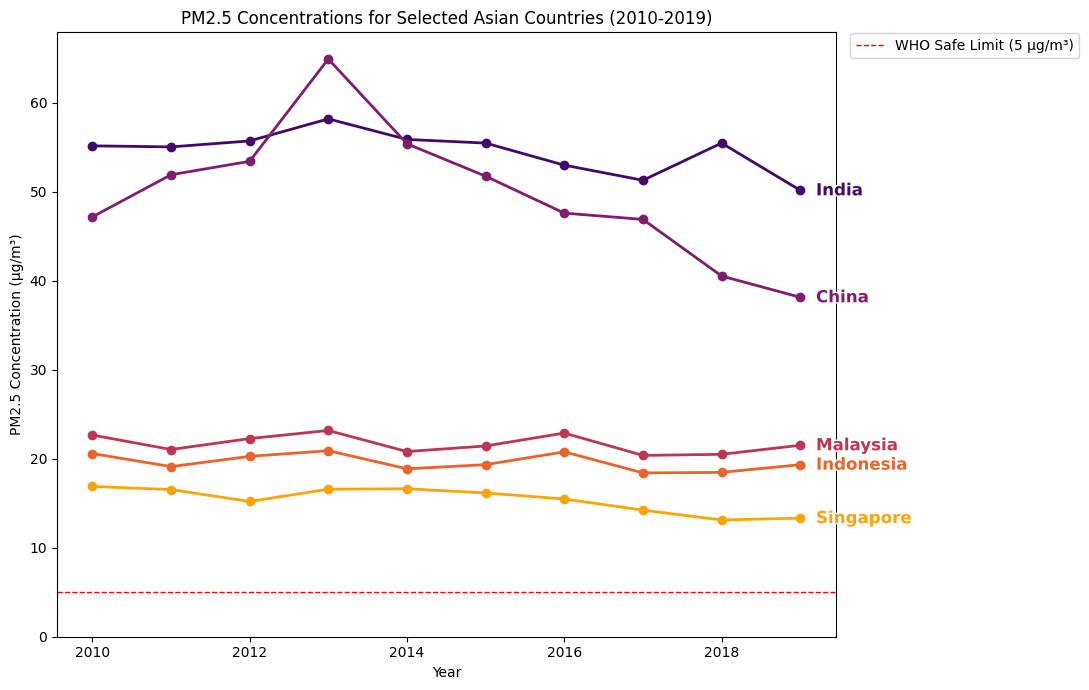

In [126]:
macro_countries = ["India", "China", "Malaysia", "Indonesia", "Singapore",]

colors = plt.cm.inferno(np.linspace(0.2, 0.8, len(macro_countries)))
plt.figure(figsize=(11, 7))

for c, color in zip(macro_countries, colors):
    c_df = ap_macro_df[ap_macro_df["Location"] == c].sort_values("Year")
    plt.plot(c_df["Year"], c_df["PM25"], marker="o", linewidth=2, color=color)
    x = c_df["Year"].values[-1]
    y = c_df["PM25"].values[-1]
    plt.text(x + 0.2, y, c, color=color, va="center", fontsize=12, weight="bold",
             clip_on=False, path_effects=[pe.withStroke(linewidth=2, foreground="white")])

plt.axhline(5, linestyle="--", linewidth=1, color="red", label="WHO Safe Limit (5 µg/m³)")
plt.title("PM2.5 Concentrations for Selected Asian Countries (2010-2019)")
plt.xlabel("Year")
plt.ylabel("PM2.5 Concentration (µg/m³)")
plt.ylim(bottom=0)
# plt.figtext(
#     0.39, 0.135,
#     "WHO Safe Limit (5 µg/m³)",
#     ha="left", va="bottom", fontsize=11
# )
plt.legend(bbox_to_anchor=(1.01, 1.01), loc="upper left")
plt.tight_layout()
plt.show()

In [122]:
ap_micro_temp_df = ap_df.copy()
ap_micro_temp_df = ap_micro_temp_df.dropna(subset=["Year", "PM25", "Location", "Dim1"])

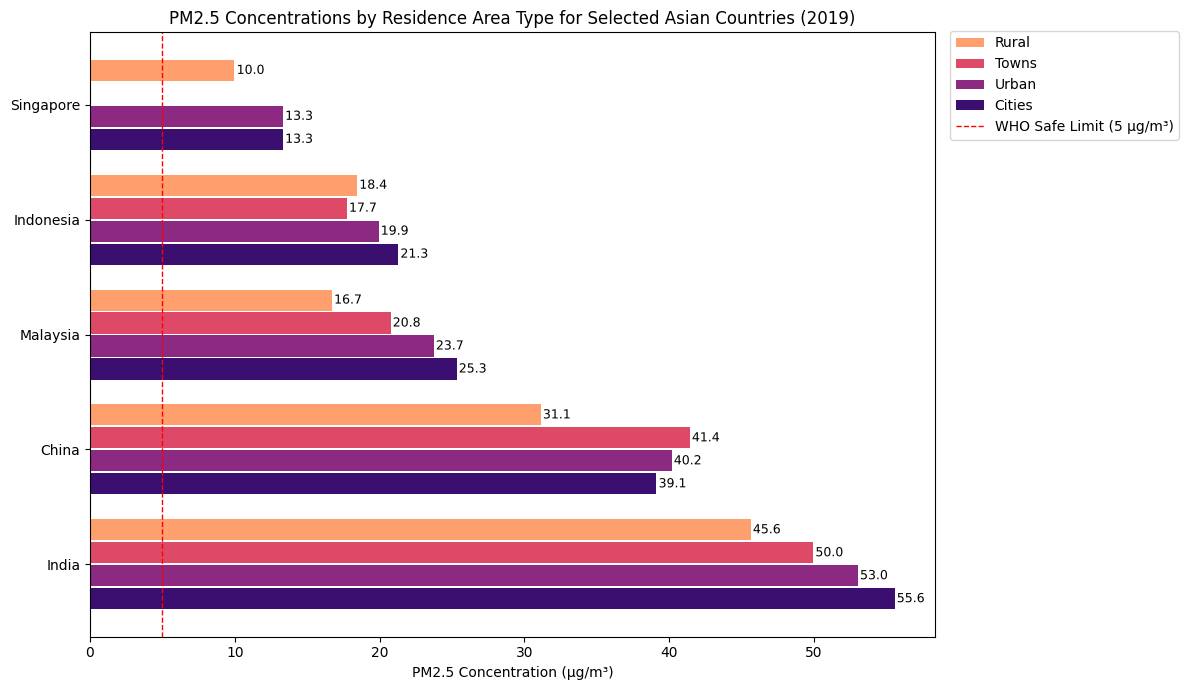

In [123]:
year = 2019
micro_countries = ["India", "China", "Malaysia", "Indonesia", "Singapore"]
dim1 = ["Cities", "Urban", "Towns", "Rural"]

ap_micro_df = ap_micro_temp_df[
    (ap_micro_temp_df["Year"] == year) &
    (ap_micro_temp_df["Location"].isin(micro_countries)) &
    (ap_micro_temp_df["Dim1"].isin(dim1))
].copy()

ap_micro_agg_df = (ap_micro_df
                   .groupby(["Location", "Dim1"], as_index=False)["PM25"]
                   .mean())

ap_micro_wide_df = (ap_micro_agg_df
                    .pivot(index="Location", columns="Dim1", values="PM25")
                    .reindex(micro_countries))

colors = plt.cm.magma(np.linspace(0.2, 0.8, len(dim1)))

y = np.arange(len(micro_countries))
group_height = 0.80
bar_h = group_height / len(dim1)

fig, ax = plt.subplots(figsize=(12, 7))

bar_handle = {}
for j, (d, color) in enumerate(zip(dim1, colors)):
    widths = ap_micro_wide_df[d].values
    ypos = y - group_height/2 + (j + 0.5) * bar_h
    bars = ax.barh(ypos, widths, height=bar_h * 0.92, color=color)
    bar_handle[d] = bars[0]
    for yi, w in zip(ypos, widths):
        if pd.notna(w):
            ax.text(w + 0.15, yi, f"{w:.1f}", va="center", fontsize=9,
                    path_effects=[pe.withStroke(linewidth=2, foreground="white")])

who_line = ax.axvline(5, linestyle="--", linewidth=1, color="red")
ax.set_yticks(y)
ax.set_yticklabels(micro_countries)
ax.set_xlabel("PM2.5 Concentration (µg/m³)")
ax.set_title(f"PM2.5 Concentrations by Residence Area Type for Selected Asian Countries ({year})")
ax.set_xlim(left=0)

legend_order = ["Rural", "Towns", "Urban", "Cities"]
handles = [bar_handle[k] for k in legend_order] + [who_line]
labels = legend_order + ["WHO Safe Limit (5 µg/m³)"]
ax.legend(handles, labels, bbox_to_anchor=(1.01, 1.014), loc="upper left")

plt.tight_layout()
plt.show()

In [124]:
sg_files = sorted(glob("Historical PM2.5 *.csv"))
sg_action_df = pd.concat([pd.read_csv(f) for f in sg_files], ignore_index=True)
sg_action_df.head()

,date,timestamp,update_timestamp,region,region_id,location_longitude,location_latitude,pm25_one_hourly
0,2016-02-10,2016-02-10T14:00:00+08:00,2016-03-03T21:37:03+08:00,south,rSO,103.82,1.29587,9.0
1,2016-02-10,2016-02-10T14:00:00+08:00,2016-03-03T21:37:03+08:00,north,rNO,103.82,1.41803,15.0
2,2016-02-10,2016-02-10T14:00:00+08:00,2016-03-03T21:37:03+08:00,east,rEA,103.94,1.35735,14.0
3,2016-02-10,2016-02-10T14:00:00+08:00,2016-03-03T21:37:03+08:00,central,rCE,103.82,1.35735,10.0
4,2016-02-10,2016-02-10T14:00:00+08:00,2016-03-03T21:37:03+08:00,west,rWE,103.70,1.35735,15.0


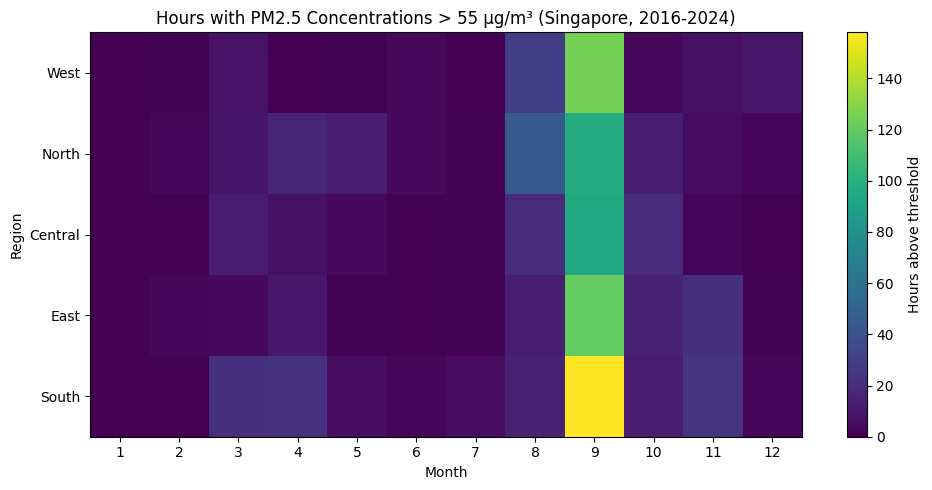

In [125]:
sg_action_df["timestamp"] = pd.to_datetime(sg_action_df["timestamp"], errors="coerce")
sg_action_df["pm25_one_hourly"] = pd.to_numeric(sg_action_df["pm25_one_hourly"], errors="coerce")
sg_action_df = sg_action_df.dropna(subset=["timestamp", "region", "pm25_one_hourly"])

sg_action_df["year"] = sg_action_df["timestamp"].dt.year
sg_action_df["month"] = sg_action_df["timestamp"].dt.month

threshold = 55

sg_action_df["exceed"] = (sg_action_df["pm25_one_hourly"] > threshold).astype(int)

agg = (sg_action_df.groupby(["region", "month"], as_index=False)["exceed"]
         .sum()
         .rename(columns={"exceed": "hours_above_threshold"}))

region_order = ["west", "north", "central", "east", "south"]
heat = (agg.pivot(index="region", columns="month", values="hours_above_threshold")
          .reindex(region_order))

plt.figure(figsize=(10, 5))
plt.imshow(heat.fillna(0).values, aspect="auto")

plt.yticks(np.arange(len(heat.index)), heat.index.str.title())
plt.xticks(np.arange(12), [str(m) for m in range(1, 13)])
plt.xlabel("Month")
plt.ylabel("Region")
plt.title(f"Hours with PM2.5 Concentrations > {threshold} µg/m³ (Singapore, {sg_action_df['year'].min()}-{sg_action_df['year'].max()})")

cbar = plt.colorbar()
cbar.set_label("Hours above threshold")

plt.tight_layout()
plt.show()